In [65]:
import os
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing

from torch_geometric.data import Dataset
from torch_geometric.loader import DataLoader
from torch.nn import Sequential, Linear, ReLU, LayerNorm
import torch.nn.functional as F
from torch_geometric.utils import to_networkx, from_networkx
import networkx as nx
import imageio
from tqdm.notebook import tqdm
import random
import pickle
import shutil
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [66]:
from torch_scatter import scatter_add, scatter_mean

In [116]:
from typing_extensions import Literal


class Trainer:
    """
    Trainer class for training and evaluating the MeshGraphNet model.

    This class manages:
    - Training process using graph-based data.
    - Model evaluation through test rollouts.
    - Model checkpointing and saving.

    Parameters:
    - model (torch.nn.Module): The GNN model to be trained.
    - optimizer (torch.optim.Optimizer): Optimizer for training.
    - device (torch.device): Target computing device (CPU/GPU).
    - train_stats (tuple): Normalization statistics (mean, std) for input/output features.
    """

    def __init__(
        self, model, optimizer, device, loss_type: Literal["mse", "mae"] = "mse"
    ):
        self.model = model
        self.optimizer = optimizer
        self.device = device
        if loss_type == "mse":
            self.loss_fn = F.mse_loss
        elif loss_type == "mae":
            self.loss_fn = F.l1_loss
        else:
            print(f"Unsupported loss function: {loss_type}!")
            print(f"Falling back to MSE loss.")
            self.loss_fn = F.mse_loss
        # Training and test history
        self.train_history = []
        self.extr_test_history = []
        self.gen_test_history = []

        # Create a directory for saving trained models
        self.cur_dir = os.getcwd()
        self.model_dir = os.path.join(self.cur_dir, "saved_models")
        self.gen_loss = 0.0  # Initialize generalization loss

    def train(self, graph: Data):
        # Forward pass through the model
        pred = self.model(graph)
        target = graph.y.to(self.device)

        # Compute MSE loss
        loss = self.loss_fn(pred, target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Store loss history
        self.loss = loss.cpu().detach().numpy()
        self.train_history.append(self.loss)

    def test(self, test_loader, gen_roll_out=False, experiment_name="Val"):
        self.model.eval()  # Set model to evaluation mode
        # Store overall test loss history
        # self.gen_test_history.append(
        #     self.gen_loss_pos + self.gen_loss_vel + self.gen_loss_stress
        # )

    def save_model(self):
        self.model_dir.mkdir(parents=True, exist_ok=True)
        # Save model using the generalization loss as part of the filename
        filename = f"GenLoss_{self.gen_loss_pos:.2f}m_{self.gen_loss_vel:.2f}mps_{self.gen_loss_stress:.2f}Nms2.pth"
        self.path = self.model_dir / filename
        torch.save(self.model.state_dict(), self.path)


# Trainer Instance created

In [117]:
device = "cpu"
trainer = Trainer(MODEL, optimizer, device, loss_type="mse")
# Clear PyTorch CUDA cache
torch.cuda.empty_cache()

In [12]:
def create_input_graph(
    graph,
    x,
    v,
    node_bc,
    node_force,
    node_stats,
    edge_stats,
):
    """All inputs not normalized"""
    boundary_condition = node_bc  # 1 fixed, 0 free
    node_force = node_force  # external force on node
    x = x

    categorical_node_features = boundary_condition.unsqueeze(1)
    valued_node_features = torch.concat([x, v, node_force], dim=1)

    src, dst = graph.edge_index
    xij = x[dst] - x[src]
    xij_norm = torch.norm(xij, dim=1).unsqueeze(1)

    edge_features = torch.concat([xij, xij_norm], dim=1)

    _edge_attr = normalize(edge_features, edge_stats)
    _x = torch.concat(
        [categorical_node_features, normalize(valued_node_features, node_stats)], dim=1
    )
    _x[-1] = graph.x[-1]  # Keep the force node features from the future unchanges
    return graph.clone().to(device).update(x=_x, edge_attr=_edge_attr)


In [ ]:
import json
from preprocess_data import Stats, denormalize


def mae(target, pred):
    return torch.mean(torch.abs(target - pred))


stats_folder = Path("./Results/train/stats")
model = MODEL.to(device)
graph = dataset[0].to(device)
test_dataset = InMemoryTimeStepDataset("dataset/beam/test")
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
###
dt = 0.08  # Time step size for integration
with open(stats_folder / "stats.json", "r") as f:
    stats = json.load(f)
node_stats = Stats.from_dict(stats["node"])
edge_stats = Stats.from_dict(stats["edge"])
target_stats = Stats.from_dict(stats["target"])
with torch.no_grad():
    # Store errors for evaluation
    error_x = []
    error_v = []
    error_stress = []
    pred_graphs = []
    true_graphs = []
    for t, graph in enumerate(test_loader):
        target = graph.y.to(device)
        if t > 0:
            graph = create_input_graph(
                graph=graph,
                x=x_new,
                v=v_new,
                node_bc=graph.x[:, 0],
                node_force=graph.x[:, :-3],
                node_stats=node_stats,
                edge_stats=edge_stats,
            )

        pred = model(graph.to(device))

        pred_denorm = denormalize(pred, target_stats)
        target_denorm = denormalize(target, target_stats)

        a = pred_denorm[:, :3]
        von_mises = pred_denorm[:, 3]
        a_true = target_denorm[:, :3]
        von_mises_true = target_denorm[:, 3]

        # exclude the first dimension (boundary condition)
        node_features_denorm = denormalize(graph.x[:, 1:], node_stats)
        x = node_features_denorm[:, :3]
        v = node_features_denorm[:, 3:6]

        # integrate
        v_new = v + a * dt
        x_new = x + 0.5 * (v + v_new) * dt

        # Use new graph to calculate error
        x_true = graph.y_pos_t
        v_true = graph.y_vel_t
        mae_pos = mae(x_true, x_new)
        mae_vel = mae(v_true, v_new)
        mae_stress = mae(von_mises_true, von_mises)

        error_x.append(mae_pos)
        error_v.append(mae_vel)
        error_stress.append(mae_stress)

pred_graphs, true_graphs, error_x, error_v, error_stress

Found 1 sample files
Loaded the dataset with 50 samples


RuntimeError: The size of tensor a (13) must match the size of tensor b (9) at non-singleton dimension 1

In [ ]:
def test(
    test_loader,
    model,
    device,
    stats_folder: Path,
    gen_roll_out=False,
    experiment_name="Val",
):
    # Load normalization statistics for input and output features
    with open(stats_folder / "stats.json", "r") as f:
        stats = json.load(f)

    with torch.no_grad():  # Disable gradient tracking for evaluation
        lst_error_pos = []
        lst_error_vel = []
        lst_error_stress = []
        lst_pred_graphs = []
        lst_true_graphs = []
        dt = 0.08  # Time step for updating positions and velocities

        # Extract output feature statistics (mean and std for acceleration and stress)
        (std_acc, mean_acc), (std_sig, mean_sig) = stat_out_feat
        std_acc, mean_acc = std_acc.to(device), mean_acc.to(device)
        std_sig, mean_sig = std_sig.to(device), mean_sig.to(device)

        # Iterate over the test DataLoader
        for i, (prev_graph, current_graph, next_graph) in enumerate(test_loader):
            # Move graphs to the specified device (CPU/GPU)
            prev_graph, current_graph, next_graph = (
                prev_graph.to(device),
                current_graph.to(device),
                next_graph.to(device),
            )

            # Initialize the first time step if it's the first iteration
            if i == 0:
                graph_t0_minus_1 = prev_graph
                graph_t0 = current_graph

            # Create the input graph using the previous and current graphs
            ingraph = create_input_graph(
                graph_t0_minus_1, graph_t0, device, stat_in_feat
            )

            # Predict acceleration and stress tensor using the model
            node_acc, node_sig = model(
                ingraph.detach()
            )  # Detach to avoid unwanted gradient tracking

            # Rescale predicted accelerations and stresses to their original scale
            node_acc_rescaled = node_acc * std_acc + mean_acc
            node_sig_rescaled = node_sig * std_sig + mean_sig

            # Extract previous position, velocity
            node_x_t0 = graph_t0.x  # Current positions
            node_v_t0 = graph_t0.x_vel_t  # Current velocities
            node_f_t0 = graph_t0.x_node_force  # Current forces

            # Update velocity using acceleration
            node_v_t1 = node_v_t0 + node_acc_rescaled * dt
            # Update position using velocity
            node_x_t1 = node_x_t0 + 0.5 * (node_v_t0 + node_v_t1) * dt
            # Copy external forces from the next graph (assumed to be known)
            node_f_t1 = next_graph.x_node_force

            # Copy boundary conditions and edge index
            node_bc = graph_t0.x_bc
            edge_index = graph_t0.edge_index

            # Save the previous graph state for the next iteration
            graph_t0_minus_1 = Data(
                x=graph_t0.x.clone(),
                x_vel_t=graph_t0.x_vel_t.clone(),
                x_node_force=graph_t0.x_node_force.clone(),
                x_bc=graph_t0.x_bc.clone(),
                edge_index=graph_t0.edge_index.clone(),
            )

            # Create the updated graph for the current time step
            graph_t0 = Data(edge_index=edge_index)
            graph_t0.x = node_x_t1
            graph_t0.x_vel_t = node_v_t1
            graph_t0.x_node_force = node_f_t1
            graph_t0.x_bc = node_bc
            # store the predicted acc tensor (they are stored and not used in rollout calc)
            # store the predicted stress tensor
            graph_t0.y_acc_t = node_acc_rescaled
            graph_t0.y_sig_t = node_sig_rescaled

            # Compute prediction errors
            error_pos = torch.abs(graph_t0.x - next_graph.x)  # Position error
            error_vel = torch.abs(
                graph_t0.x_vel_t - next_graph.x_vel_t
            )  # Velocity error
            error_stress = torch.abs(
                node_sig_rescaled - next_graph.y_sig_t
            )  # Stress tensor error

            # Compute Mean Absolute Errors (MAE)
            mae_pos = torch.mean(error_pos).item()
            mae_vel = torch.mean(error_vel).item()
            mae_stress = torch.mean(error_stress).item()

            # Store errors for evaluation
            lst_error_pos.append(mae_pos)
            lst_error_vel.append(mae_vel)
            lst_error_stress.append(mae_stress)
            lst_pred_graphs.append(graph_t0)
            lst_true_graphs.append(next_graph)

    return (
        lst_pred_graphs,
        lst_true_graphs,
        lst_error_pos,
        lst_error_vel,
        lst_error_stress,
    )

# Training Code

In [1]:
import os
from pathlib import Path
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing

from torch_geometric.data import Dataset
from torch_geometric.loader import DataLoader
from torch.nn import Sequential, Linear, ReLU, LayerNorm
import torch.nn.functional as F
from torch_geometric.utils import to_networkx, from_networkx
import networkx as nx
import imageio
from tqdm import tqdm
import random
import pickle
import shutil
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from in_memory_dataset import InMemoryTimeStepDataset
from models.vinay_mgn import MeshGraphNet
from typing_extensions import Literal

from trainer import Trainer

# Define model hyperparameters
num_messages = 8  # Number of message-passing steps in the GNN
latent_dim = 128  # Size of the latent feature space
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the MeshGraphNet model
MODEL = MeshGraphNet(
    node_channels=10,
    edge_channels=4,
    latent_size=latent_dim,
    num_msgs=num_messages,
)
MODEL.to(device)
optimizer = torch.optim.Adam(MODEL.parameters(), lr=3e-5)
trainer = Trainer(MODEL, optimizer, device, loss_type="mse")
torch.cuda.empty_cache()

total_epochs = 50
progress_bar = tqdm(total=total_epochs, desc="Training Progress")
data_dir = "dataset/beam/train"
batch_size = 4
shuffle = True
dataset = InMemoryTimeStepDataset(data_dir)
dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=shuffle,
    drop_last=True,  # Ensures all batches have the same size
    num_workers=0,
)
test_loader = DataLoader(
    dataset[:50],
    batch_size=1,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)
epoch_bar = tqdm(range(total_epochs), desc="Epochs")
for epoch in epoch_bar:
    for batch in tqdm(dataloader, desc="Batches", leave=False):
        # print("hey")
        trainer.train(batch)
    trainer.epoch_end()
    trainer.save_model()
    epoch_bar.set_postfix({"last_loss": f"{trainer.loss:.6f}"})

    trainer.test(test_loader=test_loader, gen_roll_out=False, experiment_name="Val")


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Found 6 sample files
Loaded the dataset with 300 samples


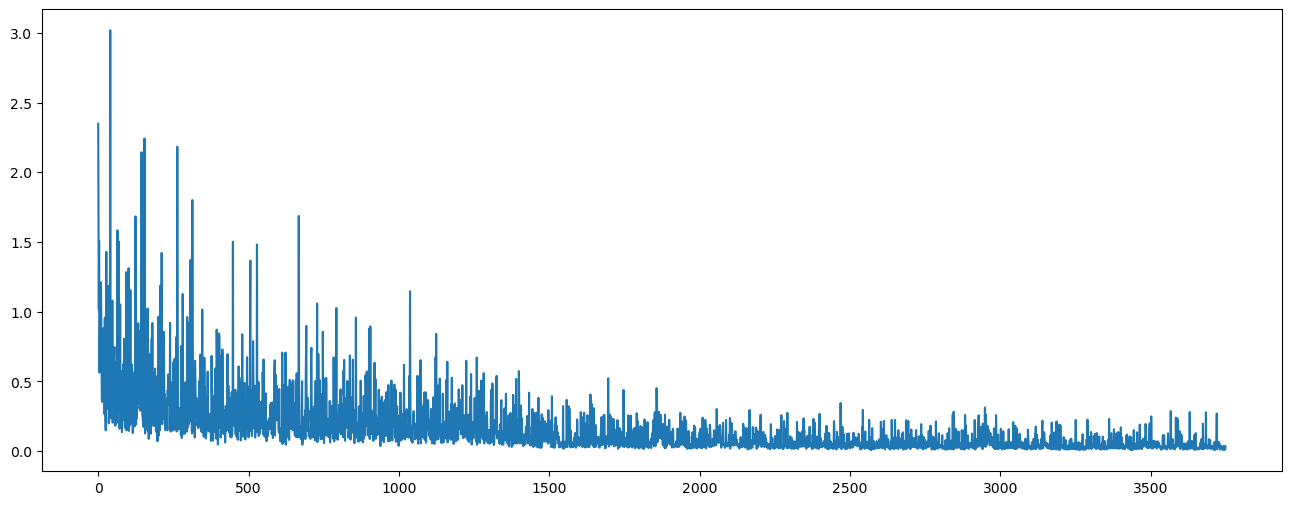

In [7]:
plt.figure(figsize=(16, 6))
plt.plot(trainer.train_history)
plt.show()

## Model Management: Keeping Best Models & Loading the Best Checkpoint

### **1. Overview**
To manage and efficiently store trained models, we:
1. **Extract loss values from filenames**.
2. **Compute a weighted combined loss**.
3. **Keep only the best-performing models**.
4. **Load the best checkpoint for inference/testing**.

---

### **2. Functions**
#### **a) `parse_loss_from_filename(filename)`**
- Extracts **position, velocity, and angular velocity errors** from model filenames.
- Expected format:

In [8]:
def parse_loss_from_filename(filename):
    """
    Extracts position, velocity, and angular velocity losses from a model filename.

    Expected filename format:
    'GenLoss_<pos_loss>m_<vel_loss>mps_<angvel_loss>Nms2.pth'

    Parameters:
    - filename (str): Model filename.

    Returns:
    - pos_loss (float): Position error.
    - vel_loss (float): Velocity error.
    - angvel_loss (float): Angular velocity error.
    """
    parts = filename.split("_")
    pos_loss = float(parts[1].replace("m", ""))
    vel_loss = float(parts[2].replace("mps", ""))
    angvel_loss = float(parts[3].replace("Nms2.pth", ""))
    return pos_loss, vel_loss, angvel_loss


def combined_loss(
    pos_loss, vel_loss, angvel_loss, pos_weight=1.0, vel_weight=1.0, angvel_weight=1.0
):
    """
    Computes the weighted combined loss from position, velocity, and angular velocity errors.

    Parameters:
    - pos_loss (float): Position loss.
    - vel_loss (float): Velocity loss.
    - angvel_loss (float): Angular velocity loss.
    - pos_weight (float): Weight for position loss (default = 1.0).
    - vel_weight (float): Weight for velocity loss (default = 1.0).
    - angvel_weight (float): Weight for angular velocity loss (default = 1.0).

    Returns:
    - float: Weighted sum of losses.
    """
    return pos_weight * pos_loss + vel_weight * vel_loss + angvel_weight * angvel_loss


def keep_top_models(
    model_dir, top_n=20, pos_weight=1.0, vel_weight=1.0, angvel_weight=1.0
):
    """
    Retains only the top `top_n` best models based on their weighted combined loss and removes the rest.

    Parameters:
    - model_dir (str): Directory where model files are stored.
    - top_n (int): Number of top models to keep (default = 20).
    - pos_weight (float): Weight for position loss.
    - vel_weight (float): Weight for velocity loss.
    - angvel_weight (float): Weight for angular velocity loss.

    Deletes:
    - All models except the top `top_n` models.
    """
    if not os.path.exists(model_dir):
        print("Model directory does not exist.")
        return

    # Get list of all saved models
    model_files = [f for f in os.listdir(model_dir) if f.endswith(".pth")]

    if not model_files:
        print("No model files found.")
        return

    # Extract losses from filenames and sort models by combined loss
    model_files.sort(
        key=lambda x: combined_loss(
            *parse_loss_from_filename(x), pos_weight, vel_weight, angvel_weight
        )
    )

    # Keep only the top `top_n` models and delete the rest
    for model_file in model_files[top_n:]:
        os.remove(os.path.join(model_dir, model_file))
        # print(f"Deleted {model_file}")


def load_best_model(trainer, pos_weight=1.0, vel_weight=1.0, angvel_weight=0.0):
    """
    Loads the best model based on the lowest weighted combined loss.

    Parameters:
    - trainer (Trainer): Instance of the `Trainer` class.
    - pos_weight (float): Weight for position loss.
    - vel_weight (float): Weight for velocity loss.
    - angvel_weight (float): Weight for angular velocity loss.

    Returns:
    - None (Updates trainer.model with the best model).
    """
    if not os.path.exists(trainer.model_dir):
        print("Model directory does not exist.")
        return

    # List all model files
    files = os.listdir(trainer.model_dir)

    # Filter models with the correct naming convention
    model_files = [
        file for file in files if file.startswith("GenLoss_") and file.endswith(".pth")
    ]

    if not model_files:
        print("No model files found in the directory.")
        return

    # Compute combined loss for each model
    combined_losses = [
        combined_loss(
            *parse_loss_from_filename(file), pos_weight, vel_weight, angvel_weight
        )
        for file in model_files
    ]

    # Convert to numpy array for easy processing
    combined_losses = np.array(combined_losses)

    # Identify the model with the minimum combined loss
    min_loss_index = np.argmin(combined_losses)
    min_loss_file = model_files[min_loss_index]

    print(f"Loading best model: {min_loss_file}")

    # Construct the full path to the best model
    path = os.path.join(trainer.model_dir, min_loss_file)

    # Load the model weights
    trainer.model.load_state_dict(torch.load(path, weights_only=True))


# Keep only top 20 models
keep_top_models(trainer.model_dir, top_n=5)

# Load the best model for evaluation
load_best_model(trainer)

Loading best model: GenLoss_0.00m_0.00mps_0.00Nms2.pth


# Test for a single 
## Evaluating a Single Model Prediction Against Ground Truth

### **Objective**
This script compares:
- **Predicted acceleration** (`a_t`) vs. **Ground truth acceleration**.
- **Predicted stress tensor** (`σ_t`) vs. **Ground truth stress tensor**.

---

### **Steps**
1. **Extract a single batch** from `test_dataloader`.
2. **Move data to GPU (if available)** for faster computation.
3. **Create input graph** for the model using `create_input_graph()`.
4. **Obtain predictions** for acceleration and stress tensor.
5. **Rescale predictions** back to the original scale.
6. **Compute absolute errors** and **Mean Absolute Errors (MAE)**.

In [9]:
# Fetch a single batch (previous, current, next time step)
prev, cur, nxt = next(iter(test_dataloader))

# Move graphs to the trainer's device
prev, cur, nxt = prev.to(trainer.device), cur.to(trainer.device), nxt.to(trainer.device)

# Create input graph for the model
ingph = create_input_graph(prev, cur, trainer.device, stat_in_feat)

# Model prediction
pred_node_acc, pred_node_stress = trainer.model(ingph)

# Ground truth values from the next time step
true_node_acc = nxt.y_acc_t.to(trainer.device)  # True acceleration
true_node_stress = nxt.y_sig_t.to(trainer.device)  # True stress tensor

# Extract output feature statistics for re-scaling
(std_acc, mean_acc), (std_sig, mean_sig) = stat_out_feat
std_acc, mean_acc = std_acc.to(trainer.device), mean_acc.to(trainer.device)
std_sig, mean_sig = std_sig.to(trainer.device), mean_sig.to(trainer.device)

# Rescale predictions to original scale
pred_node_acc_rescaled = pred_node_acc * std_acc + mean_acc
pred_node_stress_rescaled = pred_node_stress * std_sig + mean_sig

# Compute absolute errors
error_acc = torch.abs(pred_node_acc_rescaled - true_node_acc)
error_stress = torch.abs(pred_node_stress_rescaled - true_node_stress)

# Compute Mean Absolute Errors (MAE)
mae_acc = torch.mean(error_acc).item()
mae_stress = torch.mean(error_stress).item()

# Print the results
print(f"Single Prediction Evaluation:")
print(f"Mean Absolute Error (Acceleration): {mae_acc:.6f}")
print(f"Mean Absolute Error (Stress Tensor): {mae_stress:.6f}")

NameError: name 'test_dataloader' is not defined

## Model Rollout & Ground Truth Comparison

### **Objective**
- This script **performs a multi-step rollout using the trained model**.
- It **compares the predicted acceleration** with the **ground truth acceleration** over time.
- It also **visualizes the stress tensor components** across multiple timesteps.

---

### **Steps**
1. **Run the `test()` function** to obtain predicted graph rollouts.
2. **Extract acceleration and stress tensor predictions**.
3. **Compare predictions with ground truth** from the test dataset.
4. **Plot acceleration components (`X, Y, Z`)** over time.
5. **Plot all nine stress tensor components (`σ11, σ12, σ13, σ21, σ22, σ23, σ31, σ32, σ33`)** in a **3x3 grid**.

---

### **Expected Output**
#### **Plot 1: Acceleration Evolution**
A **1x3 grid of plots** showing:
- **X-Axis acceleration** over time of tip node.
- **Y-Axis acceleration** over time of tip node.
- **Z-Axis acceleration** over time of tip node.

Each plot compares:
- **Model-predicted acceleration** (dashed line with stars `*--`).
- **Ground truth acceleration** (dashed line with circles `o-`).

#### **Plot 2: Stress Tensor Evolution**
A **3x3 grid of subplots** showing:
- **All nine stress tensor components** (`σ11, σ12, σ13, σ21, σ22, σ23, σ31, σ32, σ33`).
- Each component's **predicted vs. ground truth values over multiple time steps**.

---

Tip Node Index Selected: 43


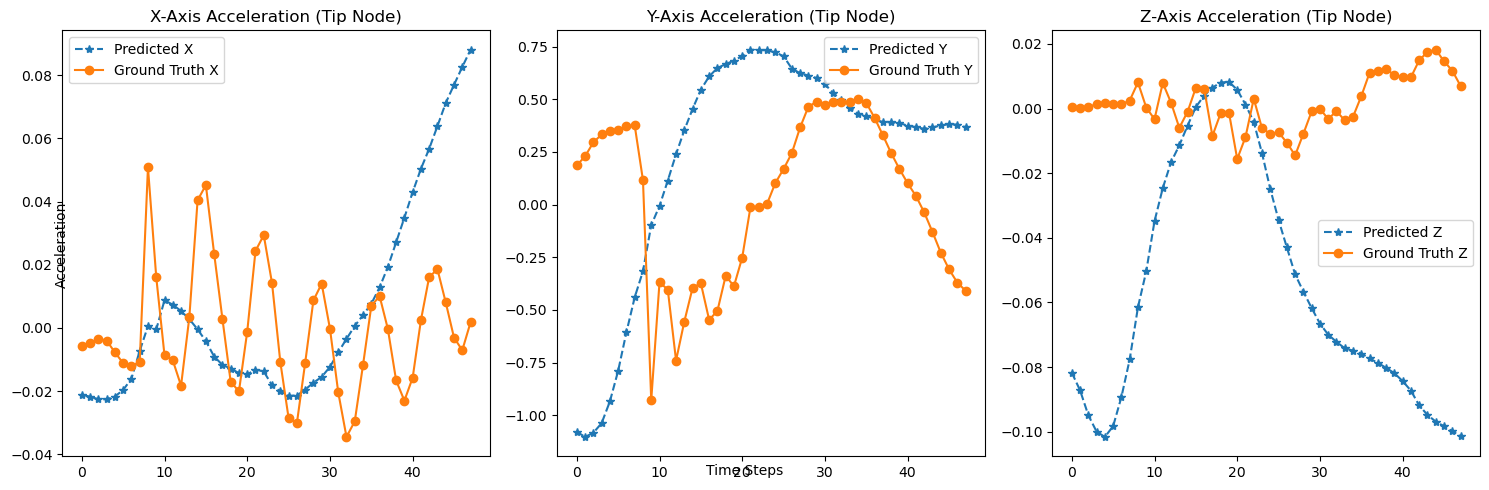

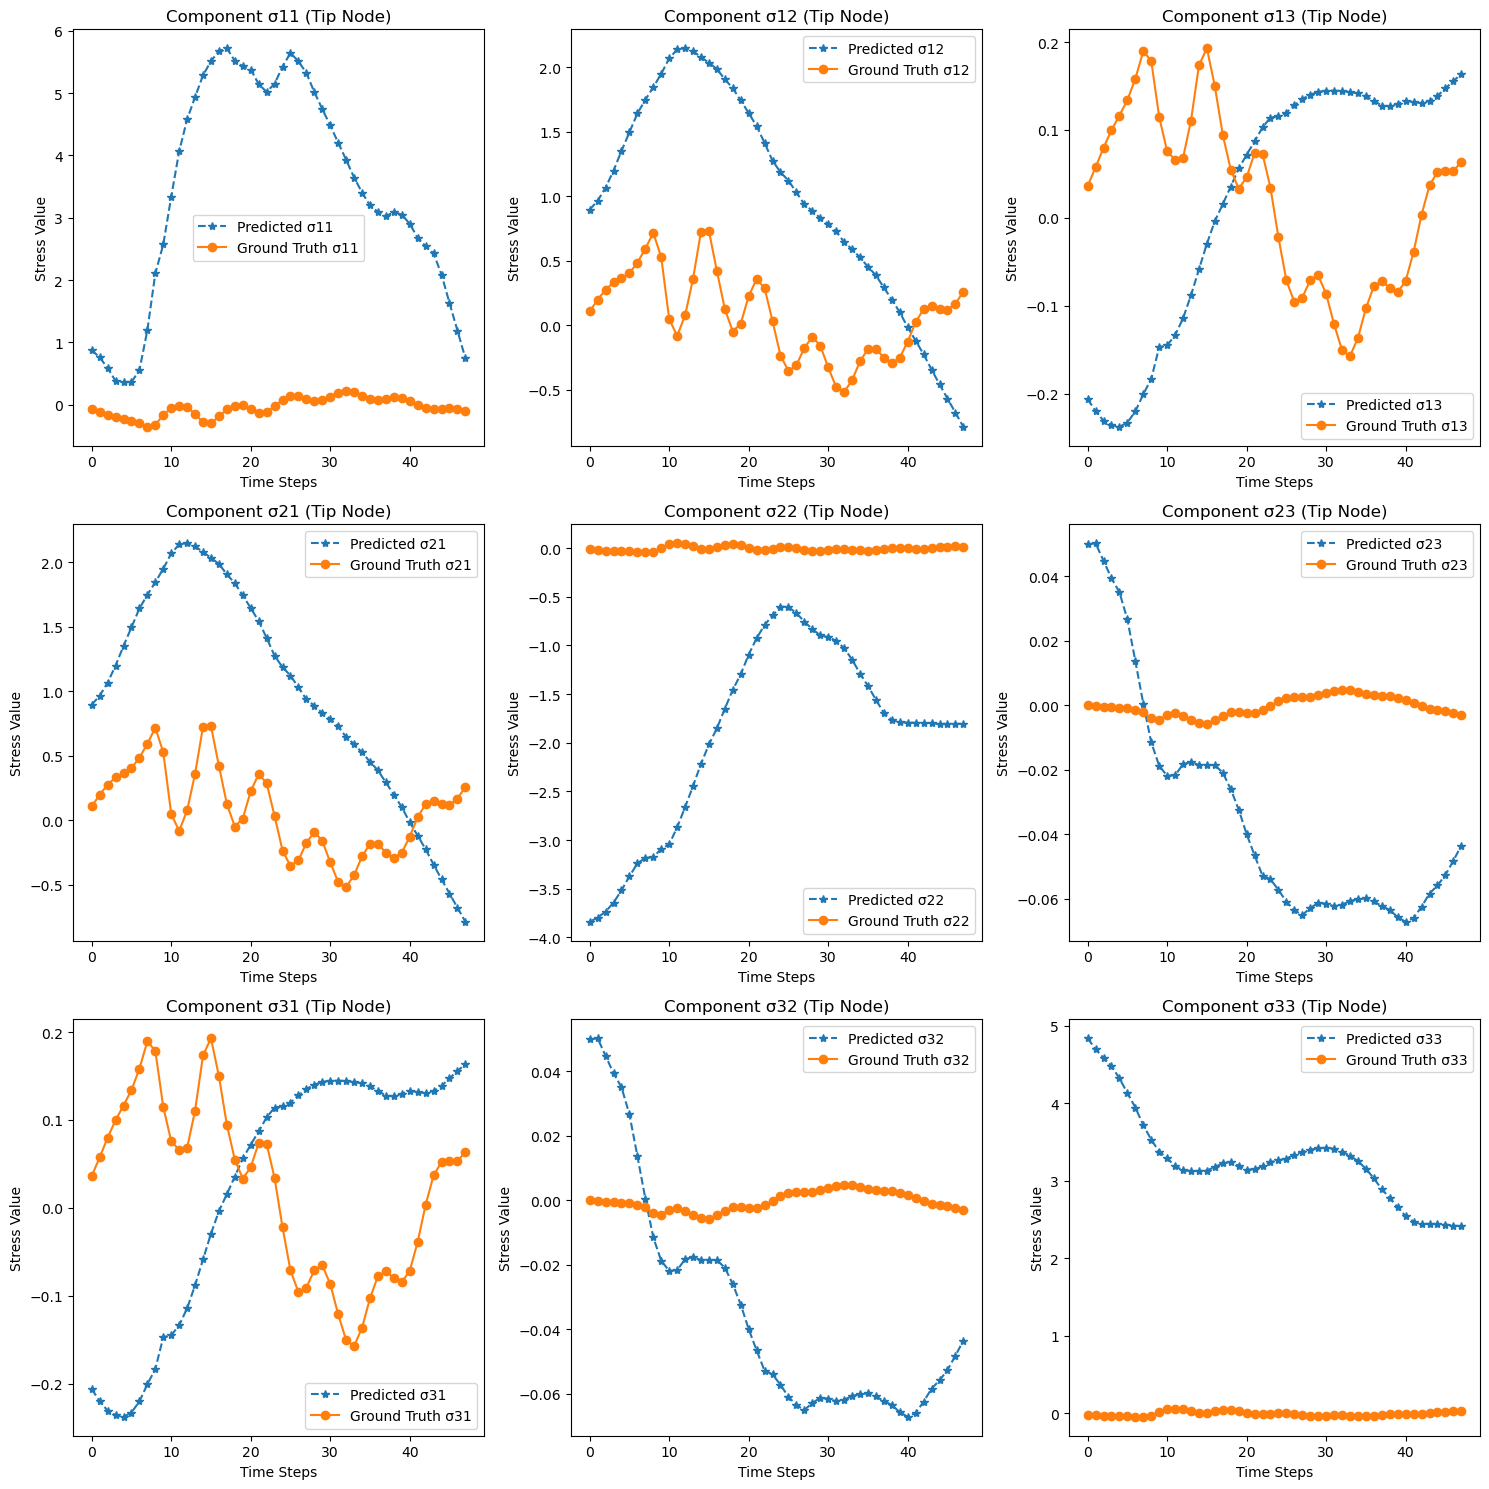

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Run the updated test function to get rollout predictions and errors
pred_graphs, true_graphs, lst_error_pos, lst_error_vel, lst_error_stress = test(
    test_dataloader,
    trainer.model,
    trainer.device,
    trainer.stat_in_feat,
    trainer.stat_out_feat,
    gen_roll_out=True,
    experiment_name="Test_Rollout",
)

# Extract acceleration and stress tensor predictions over multiple timesteps
pred_acc_rollout = []
true_acc_rollout = []
pred_stress_rollout = []
true_stress_rollout = []

# Iterate through the predicted graphs and extract acceleration & stress predictions
for pred_graph, true_graph in zip(pred_graphs, true_graphs):
    pred_acc_rollout.append(
        pred_graph.y_acc_t.cpu().detach().numpy()
    )  # Predicted acceleration
    true_acc_rollout.append(
        true_graph.y_acc_t.cpu().detach().numpy()
    )  # Ground truth acceleration

    pred_stress_rollout.append(
        pred_graph.y_sig_t.cpu().detach().numpy()
    )  # Predicted stress tensor
    true_stress_rollout.append(
        true_graph.y_sig_t.cpu().detach().numpy()
    )  # Ground truth stress tensor

# Convert to numpy arrays for visualization
pred_acc_rollout = np.array(pred_acc_rollout)  # Shape: (num_steps, num_nodes, 3)
true_acc_rollout = np.array(true_acc_rollout)  # Shape: (num_steps, num_nodes, 3)

pred_stress_rollout = np.array(pred_stress_rollout)  # Shape: (num_steps, num_nodes, 9)
true_stress_rollout = np.array(true_stress_rollout)  # Shape: (num_steps, num_nodes, 9)

## -------------------------------------
## SELECTING THE TIP NODE (EXTREME POSITION IN X, Y, Z)
## -------------------------------------

# Extract the last predicted graph to find the tip node
final_pred_graph = pred_graphs[-1]

# Convert position tensor to numpy for indexing
final_positions = final_pred_graph.x.cpu().detach().numpy()  # Shape: (num_nodes, 3)

# Find indices of the nodes with maximum X, Y, and Z positions
tip_node_x = np.argmax(final_positions[:, 0])  # Node with max X position
tip_node_y = np.argmax(final_positions[:, 1])  # Node with max Y position
tip_node_z = np.argmax(final_positions[:, 2])  # Node with max Z position

# Select the final tip node based on the maximum of all three axes
tip_node_idx = np.argmax(
    final_positions[:, 0] + final_positions[:, 1] + final_positions[:, 2]
)

print(f"Tip Node Index Selected: {tip_node_idx}")

## -------------------------------------
## PLOT 1: ACCELERATION ROLLOUT (X, Y, Z) for the Tip Node
## -------------------------------------

# Create a 1x3 grid of subplots for x, y, and z acceleration components
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Plot predicted vs. ground truth acceleration for the X-axis
ax[0].plot(pred_acc_rollout[:, tip_node_idx, 0], "*--", label="Predicted X")
ax[0].plot(true_acc_rollout[:, tip_node_idx, 0], "o-", label="Ground Truth X")
ax[0].set_title("X-Axis Acceleration (Tip Node)")
ax[0].legend()

# Plot predicted vs. ground truth acceleration for the Y-axis
ax[1].plot(pred_acc_rollout[:, tip_node_idx, 1], "*--", label="Predicted Y")
ax[1].plot(true_acc_rollout[:, tip_node_idx, 1], "o-", label="Ground Truth Y")
ax[1].set_title("Y-Axis Acceleration (Tip Node)")
ax[1].legend()

# Plot predicted vs. ground truth acceleration for the Z-axis
ax[2].plot(pred_acc_rollout[:, tip_node_idx, 2], "*--", label="Predicted Z")
ax[2].plot(true_acc_rollout[:, tip_node_idx, 2], "o-", label="Ground Truth Z")
ax[2].set_title("Z-Axis Acceleration (Tip Node)")
ax[2].legend()

# Add a common x-label and y-label
fig.text(0.5, 0.04, "Time Steps", ha="center")
fig.text(0.04, 0.5, "Acceleration", va="center", rotation="vertical")

# Show the acceleration plot
plt.tight_layout()
plt.show()

## -------------------------------------
## PLOT 2: STRESS TENSOR ROLLOUT (σ COMPONENTS - 3x3 Grid) for the Tip Node
## -------------------------------------

# Define labels for each of the 9 elements of the stress tensor
stress_labels = ["σ11", "σ12", "σ13", "σ21", "σ22", "σ23", "σ31", "σ32", "σ33"]

# Create a 3x3 grid of subplots for stress tensor components
fig, ax = plt.subplots(3, 3, figsize=(15, 15))

# Flatten the axes array for easier iteration
ax = ax.flatten()

# Loop over each component of the stress tensor
for i in range(9):
    # Plot the predicted stress component
    ax[i].plot(
        pred_stress_rollout[:, tip_node_idx, i],
        "*--",
        label=f"Predicted {stress_labels[i]}",
    )

    # Plot the ground truth stress component
    ax[i].plot(
        true_stress_rollout[:, tip_node_idx, i],
        "o-",
        label=f"Ground Truth {stress_labels[i]}",
    )

    # Set the title and legend for each subplot
    ax[i].set_title(f"Component {stress_labels[i]} (Tip Node)")
    ax[i].legend()
    ax[i].set_xlabel("Time Steps")
    ax[i].set_ylabel("Stress Value")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# **Beam Comparison GIF Generator**
## **Function: `make_beam_comparison_gif()`**
This function generates a **single animated GIF** where each frame consists of **side-by-side 3D plots**:
- **Left:** Ground Truth Beam
- **Right:** Predicted Beam

### **🔹 Parameters**
| **Parameter**      | **Type**     | **Description** |
|--------------------|-------------|----------------|
| `lst_pred_graphs` | `list[Data]` | List of **predicted** beam deformation states. |
| `lst_true_graphs` | `list[Data]` | List of **ground truth** beam deformation states. |
| `L, W, D`         | `float`      | Beam dimensions (for aspect ratio). |
| `out_gif`         | `str`        | Output filename (e.g., `"beam_comparison.gif"`). |
| `fps`             | `int`        | Frames per second (default = 4). |

### **🔹 Features**
 Uses **tetrahedral element connectivity** to interpolate stress.  

### **🔹 Example Usage**
```python
make_beam_comparison_gif(
    lst_pred_graphs=pred_graphs, 
    lst_true_graphs=true_graphs, 
    L=1.0, W=0.1, D=0.04, 
    out_gif="beam_comparison.gif",
    fps=4
)


In [ ]:
def compute_von_mises_3d(stress_9):
    sxx = stress_9[:, 0]
    sxy = stress_9[:, 1]
    sxz = stress_9[:, 2]
    syx = stress_9[:, 3]
    syy = stress_9[:, 4]
    syz = stress_9[:, 5]
    szx = stress_9[:, 6]
    szy = stress_9[:, 7]
    szz = stress_9[:, 8]
    vm = 0.5 * (
        (sxx - syy) ** 2
        + (syy - szz) ** 2
        + (szz - sxx) ** 2
        + 6.0 * (sxy**2 + syz**2 + sxz**2)
    )
    return np.sqrt(vm)


def make_beam_comparison_gif(lst_pred_graphs, lst_true_graphs, L, W, D, out_gif, fps=4):
    """
    Generates a single GIF where each frame contains two side-by-side 3D plots:
    - Left: Ground Truth Beam
    - Right: Predicted Beam

    Uses element connectivity to interpolate stress values.

    Parameters:
    - lst_pred_graphs: List of predicted PyG Data objects.
    - lst_true_graphs: List of ground truth PyG Data objects.
    - L, W, D: Beam dimensions (used for aspect ratio).
    - out_gif: Output GIF filename.
    - fps: Frames per second.
    """
    assert len(lst_pred_graphs) == len(lst_true_graphs), (
        "Mismatch in predicted and ground truth frames."
    )

    temp_dir = "temp_frames"
    if os.path.exists(temp_dir):
        shutil.rmtree(temp_dir)
    os.makedirs(temp_dir, exist_ok=True)

    frames = []

    # Extract element connectivity from the first graph: it's an Nx4 array showing 4 nodes of the tetrahedral mesh element for each node.
    first_graph = lst_true_graphs[0]
    cells = first_graph.x_element_connectivity[0][
        0
    ]  # it was a mistake that x_element_connectivity was stored as a nested list

    # Find global bounding box across all frames
    all_x, all_y, all_z = [], [], []
    vm_min, vm_max = 0.0, 0.0  # Stress range

    for g_pred, g_true in zip(lst_pred_graphs, lst_true_graphs):
        coords_pred = g_pred.x.cpu().numpy()
        coords_true = g_true.x.cpu().numpy()
        all_x.extend(coords_pred[:, 0])
        all_y.extend(coords_pred[:, 1])
        all_z.extend(coords_pred[:, 2])
        all_x.extend(coords_true[:, 0])
        all_y.extend(coords_true[:, 1])
        all_z.extend(coords_true[:, 2])

        vm_max = max(vm_max, np.max(compute_von_mises_3d(g_pred.y_sig_t.cpu().numpy())))
        vm_max = max(vm_max, np.max(compute_von_mises_3d(g_true.y_sig_t.cpu().numpy())))

    x_min, x_max = np.min(all_x), np.max(all_x)
    y_min, y_max = np.min(all_y), np.max(all_y)
    z_min, z_max = np.min(all_z), np.max(all_z)

    # Iterate over time steps to create frames
    for i, (graph_pred, graph_true) in enumerate(zip(lst_pred_graphs, lst_true_graphs)):
        print(f"Rendering frame {i}/{len(lst_pred_graphs) - 1}")

        coords_pred = graph_pred.x.cpu().numpy()
        coords_true = graph_true.x.cpu().numpy()

        stress_pred = graph_pred.y_sig_t.cpu().numpy()
        stress_true = graph_true.y_sig_t.cpu().numpy()

        vm_pred = compute_von_mises_3d(stress_pred)
        vm_true = compute_von_mises_3d(stress_true)

        fig, axarr = plt.subplots(
            1, 2, figsize=(16, 8), subplot_kw={"projection": "3d"}
        )

        cmap = plt.cm.jet
        norm = plt.Normalize(vmin=vm_min, vmax=vm_max)

        # Function to plot a beam in 3D with element connectivity
        def plot_beam(ax, coords, vm, title):
            polys = []
            face_values = []
            for tet in cells:
                tet_coords = coords[tet]  # No offset needed for separate subplots
                polys.append(tet_coords[:3])  # Use first 3 vertices for a face
                face_values.append(np.mean(vm[tet]))  # Interpolated stress

            face_values = np.array(face_values)
            face_colors = cmap(norm(face_values))

            polycoll = Poly3DCollection(polys)
            polycoll.set_facecolors(face_colors)
            polycoll.set_edgecolor("none")
            ax.add_collection3d(polycoll)

            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
            ax.set_zlim(z_min, z_max)

            ax.set_xlabel("X")
            ax.set_ylabel("Y")
            ax.set_zlabel("Z")

            ax.set_box_aspect((L * 0.1, 0.8 * W, 2.5 * D))
            ax.view_init(elev=30, azim=45)
            ax.set_title(title)

        # Left subplot: Ground Truth
        plot_beam(axarr[0], coords_true, vm_true, title="Ground Truth")

        # Right subplot: Predicted
        plot_beam(axarr[1], coords_pred, vm_pred, title="Predicted MeshGraphNet")

        cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])  # (left, bottom, width, height)
        cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
        cbar.set_label("von Mises Stress")
        # cb = fig.colorbar(mappable, ax=axarr.ravel().tolist(), shrink=0.6)
        # cb.set_label("von Mises Stress")

        frame_path = os.path.join(temp_dir, f"frame_{i:03d}.png")
        plt.tight_layout(rect=[0, 0, 0.9, 1])
        plt.savefig(frame_path, dpi=100)
        plt.close(fig)

        frames.append(imageio.imread(frame_path))

    # Create GIF
    imageio.mimsave(out_gif, frames, fps=fps, loop=0)
    print(f"GIF saved => {out_gif}")

    # Cleanup
    shutil.rmtree(temp_dir)
    print("Done.")

In [ ]:
make_beam_comparison_gif(
    lst_pred_graphs=pred_graphs,
    lst_true_graphs=true_graphs,
    L=1.0,
    W=0.1,
    D=0.04,  # Beam dimensions
    out_gif="beam_comparison.gif",
    fps=4,
)

Rendering frame 0/47
Rendering frame 1/47


/var/folders/fn/hs4_cbsj3jx6q6czlcyqvfg5tp34j9/T/ipykernel_417/3738350460.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])
/var/folders/fn/hs4_cbsj3jx6q6czlcyqvfg5tp34j9/T/ipykernel_417/3738350460.py:139: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(frame_path))


Rendering frame 2/47
Rendering frame 3/47
Rendering frame 4/47
Rendering frame 5/47
Rendering frame 6/47
Rendering frame 7/47
Rendering frame 8/47
Rendering frame 9/47
Rendering frame 10/47
Rendering frame 11/47
Rendering frame 12/47
Rendering frame 13/47
Rendering frame 14/47
Rendering frame 15/47
Rendering frame 16/47
Rendering frame 17/47
Rendering frame 18/47
Rendering frame 19/47
Rendering frame 20/47
Rendering frame 21/47
Rendering frame 22/47
Rendering frame 23/47
Rendering frame 24/47
Rendering frame 25/47
Rendering frame 26/47
Rendering frame 27/47
Rendering frame 28/47
Rendering frame 29/47
Rendering frame 30/47
Rendering frame 31/47
Rendering frame 32/47
Rendering frame 33/47
Rendering frame 34/47
Rendering frame 35/47
Rendering frame 36/47
Rendering frame 37/47
Rendering frame 38/47
Rendering frame 39/47
Rendering frame 40/47
Rendering frame 41/47
Rendering frame 42/47
Rendering frame 43/47
Rendering frame 44/47
Rendering frame 45/47
Rendering frame 46/47
Rendering frame 47

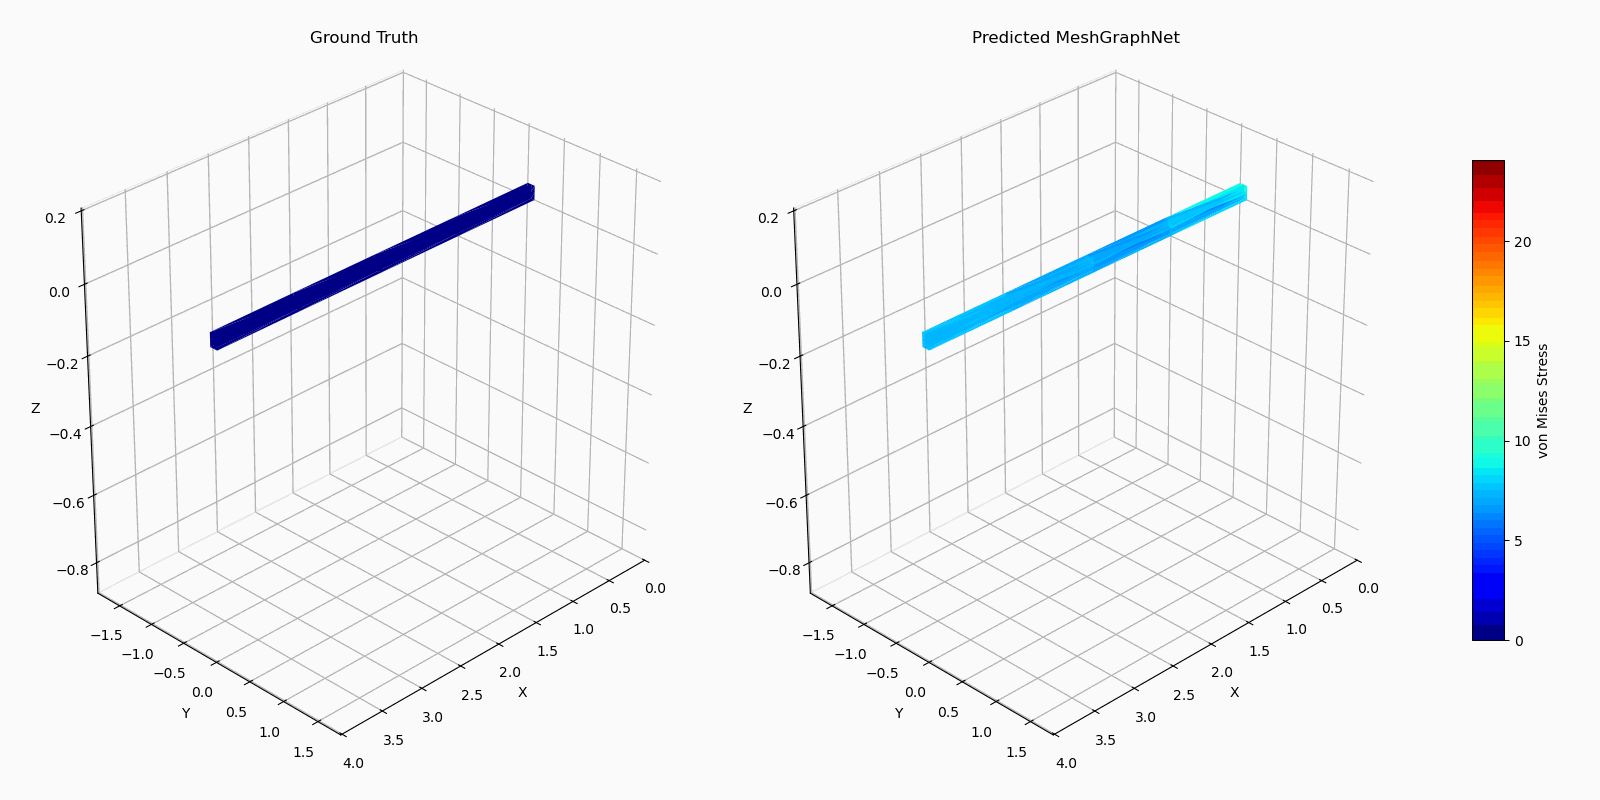

In [ ]:
from IPython.display import Image

Image(filename="beam_comparison.gif")